# Clean & Prepare Event Log

## import and setup

In [215]:
import pandas as pd
import numpy as np
import pm4py

from pathlib import Path
import yaml

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [216]:
ROOT = Path().resolve().parents[0]
SCHEMA = ROOT / "configs/schema.yaml"
STAGING = ROOT / "data/staging/snapshots.parquet"

In [217]:
df = pd.read_parquet(STAGING)

schema = yaml.safe_load(open(SCHEMA, "r", encoding="utf-8"))
col_map = schema['raw_to_canonical']

## data understanding

In [218]:
df.head(7)

,case_id,case_status,is_open,reassignment_count,reopen_count,system_update_count,met_deadline,affected_uid,reported_by_uid,opened_at,created_by_uid,created_at,updated_by_uid,updated_at,contact_channel,location_id,category_id,subcategory_id,reported_symptom,asset_id,impact_level,urgency_level,priority_level,assigned_team_gid,assigned_uid,used_knowledge_base,priority_confirmed,notify_email,root_cause_id,change_request_id,vendor_id,caused_by_change_id,resolution_id,resolved_by_uid,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 21,2016-02-29 01:23:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,True,False,False,None,None,None,None,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 642,2016-02-29 08:53:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,True,False,False,None,None,None,None,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 804,2016-02-29 11:29:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,True,False,False,None,None,None,None,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,2016-02-29 01:16:00,Created by 6,2016-02-29 01:23:00,Updated by 908,2016-03-05 12:00:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,True,False,False,None,None,None,None,code 5,Resolved by 149,2016-02-29 11:29:00,2016-03-05 12:00:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 746,2016-02-29 04:57:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,False,None,None,None,None,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
5,INC0000047,Active,True,1,0,1,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 21,2016-02-29 05:30:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,False,None,None,None,None,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00
6,INC0000047,Active,True,1,0,2,True,Caller 2403,Opened by 397,2016-02-29 04:40:00,Created by 171,2016-02-29 04:57:00,Updated by 21,2016-02-29 05:33:00,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,None,2 - Medium,2 - Medium,3 - Moderate,Group 24,Resolver 31,True,False,False,None,None,None,None,code 5,Resolved by 81,2016-03-01 09:52:00,2016-03-06 10:00:00


In [219]:
df = df.sort_values(by=['case_id', 'updated_at', 'system_update_count'])

In [220]:
df.dtypes

case_id                        object
case_status                    object
is_open                          bool
reassignment_count              int64
reopen_count                    int64
system_update_count             int64
met_deadline                     bool
affected_uid                   object
reported_by_uid                object
opened_at              datetime64[ns]
created_by_uid                 object
created_at             datetime64[ns]
updated_by_uid                 object
updated_at             datetime64[ns]
contact_channel                object
location_id                    object
category_id                    object
subcategory_id                 object
reported_symptom               object
asset_id                       object
impact_level                   object
urgency_level                  object
priority_level                 object
assigned_team_gid              object
assigned_uid                   object
used_knowledge_base              bool
priority_con

In [221]:
df.select_dtypes(include='object').nunique().sort_values()

impact_level               3
urgency_level              3
caused_by_change_id        3
priority_level             4
vendor_id                  4
contact_channel            5
case_status                9
resolution_id             17
asset_id                  50
category_id               58
assigned_team_gid         78
change_request_id        181
created_by_uid           185
reported_by_uid          207
resolved_by_uid          216
location_id              224
assigned_uid             234
root_cause_id            252
subcategory_id           254
reported_symptom         525
updated_by_uid           846
affected_uid            5244
case_id                24918
dtype: int64

In [222]:
df.select_dtypes(include='datetime').nunique().sort_values()

closed_at       2707
created_at     11552
resolved_at    18505
opened_at      19849
updated_at     50664
dtype: int64

In [223]:
df.select_dtypes(include='int').nunique().sort_values()

reopen_count             9
reassignment_count      28
system_update_count    115
dtype: int64

## fix met_deadline as final outcome

In [224]:
# event level count of met_deadline
df['met_deadline'].value_counts()

met_deadline
True     132497
False      9215
Name: count, dtype: int64

In [225]:
# no of cases in data
df['case_id'].nunique()

24918

In [226]:
# no of cases starting with true met_deadline
df.groupby('case_id')['met_deadline'].first().sum()

np.int64(24917)

In [227]:
# no of cases that last entry with false in met_deadline
(~df.groupby('case_id')['met_deadline'].last()).sum()

np.int64(9115)

In [228]:
# cases with change in met_deadline 
(df.groupby('case_id')['met_deadline'].nunique() > 1).sum()

np.int64(9114)

This implies that deadline status is fliping over timesteps, and that met_deadline is tracking the deadline status at that time. 

Only 1 case starting with false met_deadline (which didn't met the deadline from start) [24917 only true first] and 1 extra case [9115 vs 9114] has false.

In [229]:
# case that initlized with false met_deadline
met = ~df.groupby('case_id')['met_deadline'].first()
met[met].index

Index(['INC0002588'], dtype='object', name='case_id')

In [230]:
df[df['case_id'] == 'INC0002588']

,case_id,case_status,is_open,reassignment_count,reopen_count,system_update_count,met_deadline,affected_uid,reported_by_uid,opened_at,created_by_uid,created_at,updated_by_uid,updated_at,contact_channel,location_id,category_id,subcategory_id,reported_symptom,asset_id,impact_level,urgency_level,priority_level,assigned_team_gid,assigned_uid,used_knowledge_base,priority_confirmed,notify_email,root_cause_id,change_request_id,vendor_id,caused_by_change_id,resolution_id,resolved_by_uid,resolved_at,closed_at
11347,INC0002588,Active,True,0,0,0,False,Caller 3571,Opened by 325,2016-03-04 15:00:00,Created by 140,2016-03-04 15:00:00,Updated by 614,2016-03-04 15:00:00,Phone,Location 83,Category 55,Subcategory 270,Symptom 208,None,2 - Medium,2 - Medium,3 - Moderate,Group 33,Resolver 159,False,False,False,None,None,None,None,code 1,Resolved by 143,2016-03-11 10:38:00,2016-03-24 18:50:00
11348,INC0002588,Awaiting Problem,True,0,0,1,False,Caller 3571,Opened by 325,2016-03-04 15:00:00,Created by 140,2016-03-04 15:00:00,Updated by 614,2016-03-04 17:32:00,Phone,Location 83,Category 55,Subcategory 270,Symptom 208,None,2 - Medium,2 - Medium,3 - Moderate,Group 33,Resolver 159,False,False,False,None,None,None,None,code 1,Resolved by 143,2016-03-11 10:38:00,2016-03-24 18:50:00
11349,INC0002588,Resolved,True,0,0,2,False,Caller 3571,Opened by 325,2016-03-04 15:00:00,Created by 140,2016-03-04 15:00:00,Updated by 614,2016-03-11 10:38:00,Phone,Location 83,Category 55,Subcategory 270,Symptom 208,None,2 - Medium,2 - Medium,3 - Moderate,Group 33,Resolver 159,False,False,False,None,None,None,None,code 1,Resolved by 143,2016-03-11 10:38:00,2016-03-24 18:50:00
11350,INC0002588,Closed,False,0,0,3,False,Caller 3571,Opened by 325,2016-03-04 15:00:00,Created by 140,2016-03-04 15:00:00,Updated by 908,2016-03-24 18:50:00,Phone,Location 83,Category 55,Subcategory 270,Symptom 208,None,2 - Medium,2 - Medium,3 - Moderate,Group 33,Resolver 159,False,False,False,None,None,None,None,code 1,Resolved by 143,2016-03-11 10:38:00,2016-03-24 18:50:00


In [231]:
df['met_deadline'] = df.groupby('case_id')['met_deadline'].transform('last')

## time based features

In [232]:
time_df = df[schema['timestamp_cols']]

In [233]:
time_col_props = time_df.describe()
time_col_props.loc['range'] = (time_col_props.loc['max'] - time_col_props.loc['min'])
time_col_props

,opened_at,created_at,updated_at,resolved_at,closed_at
count,141712,88636,141712,138571,141712
mean,2016-04-12 22:19:09.100852736,2016-04-08 16:21:18.906539008,2016-04-19 10:49:49.286863616,2016-04-24 04:55:32.415873280,2016-04-29 23:48:41.171248640
min,2016-02-29 01:16:00,2016-02-29 01:23:00,2016-02-29 01:23:00,2016-02-29 09:04:00,2016-02-29 17:47:00
25%,2016-03-16 15:24:00,2016-03-14 16:13:00,2016-03-24 08:36:45,2016-03-25 09:17:30,2016-03-31 09:59:00
50%,2016-04-07 16:27:00,2016-04-01 20:08:00,2016-04-13 11:06:00,2016-04-15 13:09:00,2016-04-20 13:07:00
75%,2016-05-04 10:32:00,2016-04-28 16:43:00,2016-05-09 14:02:00,2016-05-12 12:36:00,2016-05-17 13:07:00
max,2017-02-16 14:17:00,2017-01-27 16:59:00,2017-02-18 15:00:00,2017-02-17 00:47:00,2017-02-18 15:00:00
range,353 days 13:01:00,333 days 15:36:00,355 days 13:37:00,353 days 15:43:00,354 days 21:13:00


In [234]:
time_df.nunique().sort_values()

closed_at       2707
created_at     11552
resolved_at    18505
opened_at      19849
updated_at     50664
dtype: int64

In [235]:
time_df.isna().sum().sort_values()

opened_at          0
updated_at         0
closed_at          0
resolved_at     3141
created_at     53076
dtype: int64

In [236]:
df.groupby('case_id')[schema['timestamp_cols']].apply(lambda case_values: case_values.isna().all()).sum()

opened_at          0
created_at     11495
updated_at         0
resolved_at     1556
closed_at          0
dtype: int64

In [237]:
df.groupby('case_id')[schema['timestamp_cols']].apply(lambda case_values: case_values.isna().any()).sum()

opened_at          0
created_at     11495
updated_at         0
resolved_at     1556
closed_at          0
dtype: int64

If the created and resolved time is unknown, its unknown for all its events. -> meaning it can not be inferred and/or imputed from its past/future events.

created_at timestamp is missing for 40-50% cases, while resolved_at is missing for around 7% cases.

Now, checking anomaly/unusual situations. Only opened, closed and updated timestamp have no unknown values.

In [238]:
group_time_obj = df.groupby('case_id')[schema['timestamp_cols']]

In [239]:
group_time_obj.first()

,opened_at,created_at,updated_at,resolved_at,closed_at
case_id,,,,,
INC0000045,2016-02-29 01:16:00,2016-02-29 01:23:00,2016-02-29 01:23:00,2016-02-29 11:29:00,2016-03-05 12:00:00
INC0000047,2016-02-29 04:40:00,2016-02-29 04:57:00,2016-02-29 04:57:00,2016-03-01 09:52:00,2016-03-06 10:00:00
INC0000057,2016-02-29 06:10:00,NaT,2016-02-29 06:26:00,2016-03-01 02:55:00,2016-03-06 03:00:00
INC0000060,2016-02-29 06:38:00,2016-02-29 06:42:00,2016-02-29 06:42:00,2016-03-02 12:06:00,2016-03-07 13:00:00
INC0000062,2016-02-29 06:58:00,2016-02-29 07:26:00,2016-02-29 07:26:00,2016-02-29 15:51:00,2016-03-05 16:00:00
...,...,...,...,...,...
INC0120304,2017-02-15 02:02:00,NaT,2017-02-15 02:02:00,2017-02-17 00:47:00,2017-02-17 00:50:00
INC0120319,2017-02-15 07:09:00,NaT,2017-02-15 07:09:00,NaT,2017-02-15 07:09:00
INC0120495,2017-02-15 11:58:00,NaT,2017-02-15 11:58:00,NaT,2017-02-16 09:51:00


In [240]:
print("\n#entries - closed before opening:", (time_df['closed_at'] < time_df['opened_at']).sum(), 
      "\n#entries - closed before updating:", (time_df['closed_at'] < time_df['updated_at']).sum(),
      "\n#entries - updated before opening:", (time_df['updated_at'] < time_df['opened_at']).sum(),
)


#entries - closed before opening: 0 
#entries - closed before updating: 0 
#entries - updated before opening: 5


### fixing opened_at

In [241]:
anomaly_open_at = df[df['updated_at'] < df['opened_at']]['case_id'].values
anomaly_open_at

array(['INC0000130', 'INC0000131', 'INC0000134', 'INC0000135',
       'INC0000164'], dtype=object)

In [242]:
case_and_time = schema['timestamp_cols'].copy()
case_and_time.insert(0, 'case_id')
case_and_time

['case_id',
 'opened_at',
 'created_at',
 'updated_at',
 'resolved_at',
 'closed_at']

In [243]:
df[df['case_id'].isin(anomaly_open_at)][case_and_time].head()

,case_id,opened_at,created_at,updated_at,resolved_at,closed_at
328,INC0000130,2016-02-29 09:41:00,2016-02-29 07:17:00,2016-02-29 07:27:00,2016-03-03 10:16:00,2016-03-08 11:00:00
329,INC0000130,2016-02-29 09:41:00,2016-02-29 07:17:00,2016-02-29 09:59:00,2016-03-03 10:16:00,2016-03-08 11:00:00
330,INC0000130,2016-02-29 09:41:00,2016-02-29 07:17:00,2016-03-01 14:13:00,2016-03-03 10:16:00,2016-03-08 11:00:00
331,INC0000130,2016-02-29 09:41:00,2016-02-29 07:17:00,2016-03-03 10:16:00,2016-03-03 10:16:00,2016-03-08 11:00:00
332,INC0000130,2016-02-29 09:41:00,2016-02-29 07:17:00,2016-03-03 10:16:00,2016-03-03 10:16:00,2016-03-08 11:00:00


such instances might occur due to system error, different timezones, script in servicenow.

The reported user median will be taken time wil be imputed the anomaly. reported_by_uid is considered because that id is the one who opened the case.

In [244]:
df[['affected_uid', 'reported_by_uid', 'created_by_uid', 'updated_by_uid']].isna().sum()

affected_uid          29
reported_by_uid     4835
created_by_uid     53076
updated_by_uid         0
dtype: int64

In [245]:
# impute such instances with 
anomaly_open_report_id = df[df['case_id'].isin(anomaly_open_at)]['reported_by_uid'].unique()
anomaly_open_report_id

array(['Opened by  62', 'Opened by  433', 'Opened by  501',
       'Opened by  40', 'Opened by  131'], dtype=object)

In [246]:
# exclude anomaly cases for describe compute
exclude_anomaly_df = df[~df['case_id'].isin(anomaly_open_at)]

exclude_anomaly_df['open_to_create'] = exclude_anomaly_df['created_at'] - exclude_anomaly_df['opened_at']
open_to_create_p75 = exclude_anomaly_df[exclude_anomaly_df['reported_by_uid'].isin(anomaly_open_report_id)].\
    groupby('reported_by_uid')['open_to_create'].quantile(0.75).astype('timedelta64[ns]')

In [247]:
open_to_create_p75.loc['Opened by  131']

Timedelta('0 days 00:13:00')

In [248]:
mask = (df['opened_at'] > df['updated_at'])
df.loc[mask, 'created_at']

328   2016-02-29 07:17:00
334   2016-02-29 07:14:00
344   2016-02-29 07:46:00
349   2016-02-29 07:46:00
436   2016-02-29 08:49:00
Name: created_at, dtype: datetime64[ns]

The system created timestamp is the first update system makes for the case. 

In [249]:
# p75 of diff for all reported_by_uid 
p75_diff = (
    df[df['updated_at'] > df['opened_at']] # use only right values
    .groupby('reported_by_uid')
    .apply(lambda x: (x['created_at'] - x['opened_at']).quantile(0.75))
)

In [250]:
# mapping to our actual df
df['p75'] = df['reported_by_uid'].map(p75_diff)

mask = df['updated_at'] < df['opened_at']
df.loc[mask, 'opened_at'] = df.loc[mask, 'created_at'] - df.loc[mask, 'p75']

df.drop(columns='p75', inplace=True)

good that opened_at has no unknown values now, but in service now incident management system; sla timer starts from the time case is opened which is mostly unknown and halts when case is resolved or on-hold.

### fixing created_at - used workaround
around 40-50% are unknown, instead using opened_at with an assumption that the case open after short while.  

In [251]:
# case_status distribution where created_at is unkown
mask = df.groupby('case_id').first()['created_at'].isna()
df.groupby('case_id').first().loc[mask, 'case_status'].value_counts()

case_status
New                   6450
Active                3438
Resolved              1543
Awaiting User Info      63
Awaiting Problem         1
Name: count, dtype: int64

In [252]:
# cases where first status is not New but later New as case_status is found.
(df.groupby('case_id').
    apply(lambda case_values: (case_values.iloc[1:]['case_status'] == 'New').any() * (case_values.iloc[0]['case_status'] != 'New'))
).sum()

np.int64(0)

In [253]:
print("#cases - all nan created_at: ", df.groupby('case_id')['created_at'].apply(lambda values: values.isna().all()).sum(),
      "#cases - any nan created_at: ", df.groupby('case_id')['created_at'].apply(lambda values: values.isna().any()).sum()
      )

#cases - all nan created_at:  11495 #cases - any nan created_at:  11495


In [254]:
# check assumption {created and updated will be same time when new case is reported} in data before impute
mask = (df['updated_at'] == df['created_at']) * df['created_at'].notna()
(df[mask]['case_status'] == 'New').value_counts()

case_status
True     11190
False     4570
Name: count, dtype: int64

In [255]:
df[mask][(df[mask]['case_status'] == 'New')]['case_id'].nunique()

9943

In [256]:
# when new case is reported and created time is known, updated and created time of that event is same. 
mask = (df['case_status'] == 'New') * df['created_at'].notna()
(df.loc[mask, 'updated_at'] == df.loc[mask, 'created_at']).value_counts()

False    12474
True     11190
Name: count, dtype: int64

Around 40% of cases have missing created_at and no business logic to impute it.

There are cases with updated_at and created_at (meaning case is just created and new) is same but case_status is not New 

In [257]:
df['this_update_time'] = df.groupby('case_id')[['updated_at']].diff(1)
df['this_update_time'] = df['this_update_time'].fillna(df['updated_at'] - df['opened_at'])
df['this_update_time']

0        0 days 00:07:00
1        0 days 07:30:00
2        0 days 02:36:00
3        5 days 00:31:00
4        0 days 00:17:00
               ...      
141707   0 days 00:00:00
141708   0 days 00:00:00
141709   0 days 01:03:00
141710   0 days 01:18:00
141711   0 days 00:00:00
Name: this_update_time, Length: 141712, dtype: timedelta64[ns]

In [258]:
df['this_update_time'].isna().sum()

np.int64(0)

In [259]:
# Check if 'new' rows accumulate significant time
df[df['case_status'] == 'New']['this_update_time'].describe()

count                        36407
mean     0 days 13:35:53.449061993
std      4 days 13:35:50.402121920
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:06:00
75%                0 days 01:02:00
max              214 days 05:38:00
Name: this_update_time, dtype: object

In [260]:
# flag suspicious cases
suspicious = df[(df['case_status'] == 'New') & 
                (df['this_update_time'] > pd.Timedelta('7 days'))]
print(f"Suspicious cases: {suspicious['case_id'].nunique()}")

#the 'New' time correlates with met deadline
df[df['case_status'] == 'New'].groupby(
    pd.cut(df['this_update_time'].dt.days, bins=[0,1,7,30,999])
)['met_deadline'].mean()

Suspicious cases: 441


this_update_time
(0, 1]       0.326819
(1, 7]       0.178415
(7, 30]      0.010563
(30, 999]    0.000000
Name: met_deadline, dtype: float64

In [261]:
# cateogrize feature — captures the non-linear relationship
df['new_status_urgency'] = pd.cut(
    df[df['case_status'] == 'New']['this_update_time'].dt.days,
    bins=[0, 1, 7, 30, 999],
    labels=['low', 'medium', 'high', 'critical']
)
# 3. Total time spent in 'New' per case as a feature
df[df['case_status'] == 'New'].groupby('case_id')['this_update_time'].sum()

case_id
INC0000045   0 days 00:07:00
INC0000047   0 days 00:17:00
INC0000057   0 days 20:44:00
INC0000060   0 days 00:04:00
INC0000062   0 days 08:53:00
                   ...      
INC0119987   0 days 00:00:00
INC0120268   0 days 00:00:00
INC0120303   0 days 00:00:00
INC0120319   0 days 00:00:00
INC0120495   0 days 00:00:00
Name: this_update_time, Length: 16397, dtype: timedelta64[ns]

In [262]:
# is created_at missing randomly
df['created_at_missing'] = df['created_at'].isna()
df.groupby('created_at_missing')['met_deadline'].mean()

created_at_missing
False    0.421759
True     0.600554
Name: met_deadline, dtype: float64

The deadline show some shift and correlation with missing value of created_at.

### fixing resolved_at

In [263]:
# majority cases have some delay in closing case.
(df['resolved_at'] != df['closed_at']).sum()

np.int64(141367)

In [264]:
# check cases where case is not closed
(df.groupby('case_id').last()['case_status'] != 'Closed').sum()

np.int64(0)

In [265]:
# is resolved same for all entries per case_id
(df.groupby('case_id')['resolved_at'].nunique(dropna=False) <= 1).all()

np.True_

In [266]:
resolved_entries = df['case_status'].eq('Resolved')
mask = df['resolved_at'].isna()

resolved_last_updated = (
    df['updated_at']
      .where(resolved_entries)
      .groupby(df['case_id'])
      .transform('max')
)
df.loc[mask, 'resolved_at'] = resolved_last_updated[mask]

In [267]:
# 0 confirm everything worked well
(df['resolved_at'] > df['closed_at']).sum()

np.int64(0)

In [268]:
mask = df['resolved_at'].isna() # remaining nan
df.loc[mask, 'resolved_at'] = df.loc[mask, 'closed_at'] # cases without Resolved status

In [269]:
df['resolved_at'].isna().sum()

np.int64(0)

### engineering remaining time to resolve the case

In [270]:
df['remaining_time'] = df['resolved_at'] - df['updated_at']

## object/categorical features

In [271]:
groupby_case_df = df.groupby('case_id')
df.select_dtypes(include='object').isna().sum().sort_values()

case_id                     0
case_status                 0
contact_channel             0
updated_by_uid              0
priority_level              0
impact_level                0
urgency_level               0
affected_uid               29
location_id                76
category_id                78
subcategory_id            111
resolved_by_uid           226
resolution_id             714
reported_by_uid          4835
assigned_team_gid       14213
assigned_uid            27496
reported_symptom        32964
created_by_uid          53076
root_cause_id          139417
change_request_id      140721
asset_id               141267
vendor_id              141468
caused_by_change_id    141689
dtype: int64

In [272]:
df.select_dtypes(include='object').head(3)

,case_id,case_status,affected_uid,reported_by_uid,created_by_uid,updated_by_uid,contact_channel,location_id,category_id,subcategory_id,reported_symptom,asset_id,impact_level,urgency_level,priority_level,assigned_team_gid,assigned_uid,root_cause_id,change_request_id,vendor_id,caused_by_change_id,resolution_id,resolved_by_uid
0,INC0000045,New,Caller 2403,Opened by 8,Created by 6,Updated by 21,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,None,None,None,None,code 5,Resolved by 149
1,INC0000045,Resolved,Caller 2403,Opened by 8,Created by 6,Updated by 642,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,None,None,None,None,code 5,Resolved by 149
2,INC0000045,Resolved,Caller 2403,Opened by 8,Created by 6,Updated by 804,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,None,2 - Medium,2 - Medium,3 - Moderate,Group 56,None,None,None,None,None,code 5,Resolved by 149


### assess location_id

In [273]:
print("#cases with all location_id record nan:", df['location_id'].isna().groupby(df['case_id']).all().sum(), "\n"
      "#cases with any location_id record nan:", df['location_id'].isna().groupby(df['case_id']).any().sum()
      )

#cases with all location_id record nan: 6 
#cases with any location_id record nan: 52


In [274]:
location_consistency = (
    groupby_case_df['location_id']
      .nunique(dropna=True)   # counts distinct non-NaN values
)

In [275]:
print("Distribution of unique location_id counts per case:")
print(location_consistency.value_counts().sort_index(), "\n")

Distribution of unique location_id counts per case:
location_id
0        6
1    24850
2       62
Name: count, dtype: int64 



In [276]:
inconsistent_locations_cases = location_consistency[location_consistency == 2].index.values
len(inconsistent_locations_cases)

62

In [277]:
df.case_id.nunique()

24918

In [278]:
temp = df[df['case_id'].isin(inconsistent_locations_cases)][['affected_uid', 'case_id', 'location_id', 'case_status']]
temp.groupby('case_id').agg(
    user      = ('affected_uid', lambda x: list(x.unique())),
    locations = ('location_id', lambda x: list(x.unique())),
    statuses  = ('case_status', lambda x: list(x.unique())),
    n_user    = ('affected_uid', 'nunique'),
    n_status  = ('case_status', 'nunique'),
    n_locs    = ('location_id', 'nunique'),
    n_rows    = ('location_id', 'count'),
).sort_values('n_user', ascending=True)


,user,locations,statuses,n_user,n_status,n_locs,n_rows
case_id,,,,,,,
INC0000086,[Caller 2403],"[Location 93, Location 98]","[New, Resolved, Closed]",1,3,2,9
INC0000129,[Caller 5340],"[Location 229, Location 135]","[New, Awaiting User Info, Resolved, Closed]",1,4,2,13
INC0000441,[Caller 1641],"[Location 15, Location 18]","[New, Resolved, Closed]",1,3,2,18
INC0000886,[Caller 5014],"[Location 143, Location 108]","[New, Active, Awaiting User Info, Resolved, Cl...",1,5,2,12
INC0001044,[Caller 1142],"[Location 143, Location 24]","[New, Active, Awaiting User Info, Resolved, Cl...",1,5,2,15
...,...,...,...,...,...,...,...
INC0096840,[Caller 4708],"[Location 165, Location 161]","[New, Active, Awaiting Vendor, Resolved, Closed]",1,5,2,6
INC0032003,[Caller 2729],"[Location 59, Location 131]","[New, Active, Awaiting Problem, Resolved, Closed]",1,5,2,8
INC0033003,[Caller 4576],"[Location 72, Location 111]","[New, Resolved, Closed]",1,3,2,4


In [279]:
for case in inconsistent_locations_cases:
    subset = df[df['case_id'] == case][['location_id', 'case_status']]
    print(f"\n── {case} ──")
    print(subset['location_id'].value_counts())


── INC0000086 ──
location_id
Location 98    8
Location 93    1
Name: count, dtype: int64

── INC0000129 ──
location_id
Location 229    11
Location 135     2
Name: count, dtype: int64

── INC0000441 ──
location_id
Location 18    16
Location 15     2
Name: count, dtype: int64

── INC0000886 ──
location_id
Location 108    8
Location 143    4
Name: count, dtype: int64

── INC0001044 ──
location_id
Location 24     10
Location 143     5
Name: count, dtype: int64

── INC0001400 ──
location_id
Location 162    10
Location 161     8
Name: count, dtype: int64

── INC0001980 ──
location_id
Location 216    8
Location 204    1
Name: count, dtype: int64

── INC0002055 ──
location_id
Location 165    10
Location 161     2
Name: count, dtype: int64

── INC0002264 ──
location_id
Location 165    2
Location 161    1
Name: count, dtype: int64

── INC0002270 ──
location_id
Location 204    4
Location 118    2
Name: count, dtype: int64

── INC0002794 ──
location_id
Location 109    15
Location 93      1
Name: 

In [280]:
# ── Check: does location change early or late in the case lifecycle? ─────────
# If agent corrects it, the change is likely early (New → Active)
# Look at position of the location change within each case

for case in inconsistent_locations_cases:
    sub = df[df['case_id'] == case][['case_status', 'location_id']].reset_index(drop=True)
    print(f"\n── {case} ──")
    print(sub)


── INC0000086 ──
  case_status  location_id
0         New  Location 93
1         New  Location 98
2         New  Location 98
3         New  Location 98
4         New  Location 98
5         New  Location 98
6         New  Location 98
7    Resolved  Location 98
8      Closed  Location 98

── INC0000129 ──
           case_status   location_id
0                  New  Location 229
1   Awaiting User Info  Location 229
2   Awaiting User Info  Location 229
3   Awaiting User Info  Location 229
4   Awaiting User Info  Location 229
5   Awaiting User Info  Location 229
6   Awaiting User Info  Location 229
7   Awaiting User Info  Location 229
8   Awaiting User Info  Location 229
9   Awaiting User Info  Location 229
10  Awaiting User Info  Location 229
11            Resolved  Location 135
12              Closed  Location 135

── INC0000441 ──
   case_status  location_id
0          New  Location 15
1          New  Location 15
2          New  Location 18
3          New  Location 18
4          New  Lo

servicenow auto-populate the location based on user records, with agent rights to edit them. Such locaton change incident happening early or when awaited user info. Can be imputed with last, as agent must have corrected before resolving and closing the case.

Same can be said for caller_id (affected_uid)
https://www.servicenow.com/community/cmdb-forum/populating-full-location-field-in-incident-record-with-full/m-p/2501340

In [281]:
(
    df.groupby('case_id')['location_id']
      .transform(lambda x: x.ffill().bfill())  # ffill handles NaNs mid-case too
).isna().sum()

np.int64(24)

In [282]:
df['location_id'] = (df.groupby('case_id')['location_id']
                     .transform(lambda x: x.ffill().bfill())  # ffill handles NaNs mid-case too
)

In [283]:
ulocation                   = df.groupby('case_id')['location_id'].nunique(dropna=False) 
ulocation_cases             = ulocation[ulocation > 1].index
change_loc_mask             = df['case_id'].isin(ulocation_cases)
df.loc[change_loc_mask,
        'location_id']      = (df.loc[change_loc_mask]
                               .groupby('case_id')['location_id']
                               .transform('last')
                               )

### assess affected_uid 
can't be inferred as all entries for cases are missing.

In [284]:
print("#cases with all affected_uid record nan:", df['affected_uid'].isna().groupby(df['case_id']).all().sum(), "\n"
      "#cases with any affected_uid record nan:", df['affected_uid'].isna().groupby(df['case_id']).any().sum()
      )

#cases with all affected_uid record nan: 3 
#cases with any affected_uid record nan: 3


In [285]:
result = df['affected_uid'].isna().groupby(df['case_id']).any()
nan_affected_uid = result[result].index.values
nan_affected_uid

array(['INC0005690', 'INC0012463', 'INC0016876'], dtype=object)

In [286]:
# verifying if queries were correctly done.
df[df['case_id'].isin(nan_affected_uid)].shape

(29, 40)

In [287]:
df[df['case_id'].isin(nan_affected_uid)]['location_id']

25376     Location 71
25377     Location 71
25378     Location 71
25379     Location 71
25380     Location 71
25381     Location 71
25382     Location 71
54161    Location 188
54162    Location 188
54163    Location 188
54164    Location 188
54165    Location 188
54166    Location 188
54167    Location 188
54168    Location 188
54169    Location 188
71654    Location 188
71655    Location 188
71656    Location 188
71657    Location 188
71658    Location 188
71659    Location 188
71660    Location 188
71661    Location 188
71662    Location 188
71663    Location 188
71664    Location 188
71665    Location 188
71666    Location 188
Name: location_id, dtype: object

Users with exactly 1 location: 4834
Users with 2+ locations:       410
Ratio:                         0.922

Avg users per location: 26.0
count     224.000000
mean       25.973214
std       126.893335
min         1.000000
25%         1.000000
50%         2.000000
75%         9.000000
max      1195.000000
Name: affected_uid, dtype: float64

Normalized Mutual Info (user → location): 0.516


<Axes: title={'center': '# unique locations per user'}, xlabel='n_locations', ylabel='n_users'>

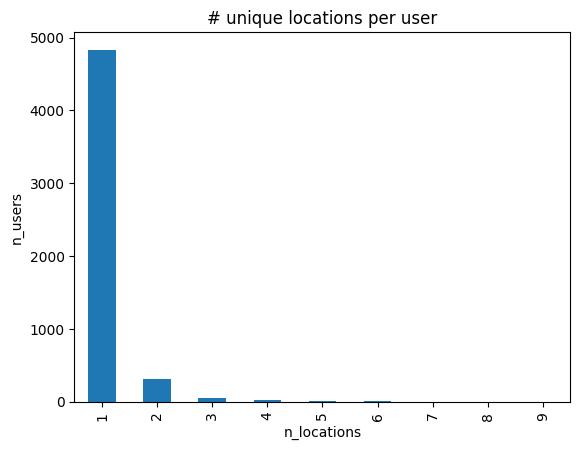

In [288]:
# ── 1. Does each user always have the same location? ─────────────────────────
user_loc = df.groupby('affected_uid')['location_id'].nunique()

print("Users with exactly 1 location:", (user_loc == 1).sum())
print("Users with 2+ locations:      ", (user_loc  > 1).sum())
print("Ratio:                        ", round((user_loc == 1).sum() / len(user_loc), 3))

# ── 2. How many users map to each location (1-to-1 vs many-to-many) ──────────
loc_user = df.groupby('location_id')['affected_uid'].nunique()
print("\nAvg users per location:", round(loc_user.mean(), 1))
print(loc_user.describe())

# ── 3. Formal association strength: Theil's U (asymmetric) ───────────────────
# "How much does knowing the user reduce uncertainty about the location?"
from sklearn.metrics import normalized_mutual_info_score

nmi = normalized_mutual_info_score(
    df['affected_uid'].astype(str),
    df['location_id'].astype(str)
)
print(f"\nNormalized Mutual Info (user → location): {nmi:.3f}")
# 0.0 = no association, 1.0 = perfect 1-to-1 mapping

# ── 4. Visual: distribution of unique locations per user ─────────────────────
user_loc.value_counts().sort_index().plot(
    kind='bar', title='# unique locations per user', xlabel='n_locations', ylabel='n_users'
)

In [289]:
groupby_case_df['affected_uid'].nunique(dropna=False).value_counts()

affected_uid
1    24915
2        3
Name: count, dtype: int64

In [290]:
df['affected_uid'].nunique()

5244

In [291]:
user_mask                   = df['affected_uid'].isna()
nan_user_location           = df.loc[user_mask, 'location_id']
nan_user_location.unique()

array(['Location 71', 'Location 188'], dtype=object)

In [292]:
df.groupby('location_id')['affected_uid'].apply(lambda x: x.nunique()).loc[['Location 71', 'Location 188']]

location_id
Location 71     30
Location 188    21
Name: affected_uid, dtype: int64

In [293]:
user_loc_nunique = df.groupby('affected_uid')['location_id'].nunique()
consistent_users = user_loc_nunique[user_loc_nunique == 1].index
(consistent_users == 'Location 181').sum()

np.int64(0)

In [294]:
user_mask                   = df['affected_uid'].isna()
nan_user_location           = df.loc[user_mask, 'location_id'].unique()
loc_nunique_users           = (df.groupby('location_id')['affected_uid']
                               .apply(lambda x: x.nunique(dropna=False)) # per locations - no of unique users
                               .loc[nan_user_location] # fiter out locations with nan user
                               )
#### logic - single location links to single user in my dataset => assumes that's valid across population
valid_impute_loc             = (loc_nunique_users == 1)
valid_impute_loc

location_id
Location 71     False
Location 188    False
Name: affected_uid, dtype: bool

In [295]:
# ── Build user → location mapping (only for consistent users) ────────────────
user_loc_nunique = df.groupby('affected_uid')['location_id'].nunique()
consistent_users = user_loc_nunique[user_loc_nunique == 1].index

user_loc_map = (
    df[df['affected_uid'].isin(consistent_users)]
      .groupby('affected_uid')['location_id']
      .first()  # same value every row, so first() is fine
)

In [296]:
user_loc_map

affected_uid
Caller 10      Location 229
Caller 1000     Location 93
Caller 1001    Location 143
Caller 1002    Location 108
Caller 1004    Location 204
                   ...     
Caller 995      Location 93
Caller 996     Location 108
Caller 997     Location 204
Caller 998     Location 204
Caller 999     Location 204
Name: location_id, Length: 4834, dtype: object

### assess category and subcategory

In [297]:
df.select_dtypes(include='object').isna().sum().sort_values()

case_id                     0
case_status                 0
contact_channel             0
updated_by_uid              0
priority_level              0
impact_level                0
urgency_level               0
location_id                24
affected_uid               29
category_id                78
subcategory_id            111
resolved_by_uid           226
resolution_id             714
reported_by_uid          4835
assigned_team_gid       14213
assigned_uid            27496
reported_symptom        32964
created_by_uid          53076
root_cause_id          139417
change_request_id      140721
asset_id               141267
vendor_id              141468
caused_by_change_id    141689
dtype: int64

In [298]:
df['category_id'].unique()

array(['Category 55', 'Category 40', 'Category 20', 'Category 9',
       'Category 53', 'Category 44', 'Category 45', 'Category 42',
       'Category 32', 'Category 8', 'Category 24', 'Category 61',
       'Category 37', 'Category 26', 'Category 23', 'Category 62',
       'Category 17', 'Category 13', 'Category 35', None, 'Category 43',
       'Category 34', 'Category 19', 'Category 46', 'Category 63',
       'Category 51', 'Category 22', 'Category 30', 'Category 31',
       'Category 15', 'Category 47', 'Category 7', 'Category 57',
       'Category 25', 'Category 56', 'Category 38', 'Category 49',
       'Category 4', 'Category 28', 'Category 41', 'Category 36',
       'Category 54', 'Category 29', 'Category 3', 'Category 27',
       'Category 33', 'Category 58', 'Category 2', 'Category 21',
       'Category 16', 'Category 50', 'Category 59', 'Category 12',
       'Category 52', 'Category 5', 'Category 6', 'Category 10',
       'Category 48', 'Category 14'], dtype=object)

In [299]:
# Are they missing together or independently?
print("\nBoth NaN:        ", (df['category_id'].isna() & df['subcategory_id'].isna()).sum())
print("Only subcat NaN: ", (df['category_id'].notna() & df['subcategory_id'].isna()).sum())
print("Only cat NaN:    ", (df['category_id'].isna() & df['subcategory_id'].notna()).sum())


Both NaN:         78
Only subcat NaN:  33
Only cat NaN:     0


In [300]:
print("#cases with all category record nan:", df['category_id'].isna().groupby(df['case_id']).all().sum(), "\n"
      "#cases with any category record nan:", df['category_id'].isna().groupby(df['case_id']).any().sum()
      )

#cases with all category record nan: 7 
#cases with any category record nan: 39


In [301]:
subcat_to_cat = df.groupby('subcategory_id')['category_id'].nunique()
print("\nSubcategories mapping to 1 category: ", (subcat_to_cat == 1).sum())
print("Subcategories mapping to 2+ category:", (subcat_to_cat  > 1).sum())


Subcategories mapping to 1 category:  206
Subcategories mapping to 2+ category: 48


In [302]:
from sklearn.metrics import normalized_mutual_info_score
for col in ['affected_uid', 'location_id', 'assigned_team_gid']:
    nmi = normalized_mutual_info_score(
        df[col].astype(str), df['category_id'].astype(str)
    )
    print(f"NMI ({col} → category_id): {nmi:.3f}")

NMI (affected_uid → category_id): 0.298
NMI (location_id → category_id): 0.084
NMI (assigned_team_gid → category_id): 0.282


In [303]:
df['category_id']    = df.groupby('case_id')['category_id'].transform(lambda x: x.ffill().bfill())
df['subcategory_id'] = df.groupby('case_id')['subcategory_id'].transform(lambda x: x.ffill().bfill())

In [304]:
df['category_id'].isna().sum()

np.int64(33)

In [305]:
case_cat_counts = df.groupby('case_id')['category_id'].nunique()
case_cat_counts[case_cat_counts > 1].sort_values()

case_id
INC0000549    2
INC0000564    2
INC0000592    2
INC0000596    2
INC0000607    2
             ..
INC0018462    3
INC0010322    3
INC0032250    3
INC0005927    4
INC0008396    4
Name: category_id, Length: 1184, dtype: int64

category and subcategory switch might be a genuine change or data entry error.

It is kept it as-is, even though the business assumption is last category are generally correct; as for estimation this incorrect and changing category may come relevant.

In [306]:
df['subcategory_id'].isna().sum()

np.int64(36)

In [307]:
# Whatever remains → sentinel, can't guess - maybe it was never inserted
df['category_id']    = df['category_id'].fillna('UNKNOWN')
df['subcategory_id'] = df['subcategory_id'].fillna('UNKNOWN')

In [308]:
# similarly filling location and affected_uid
df['location_id']    = df['location_id'].fillna('UNKNOWN')
df['affected_uid'] = df['affected_uid'].fillna('UNKNOWN')

### reported_by_uid

`resolution_id` and `resolved_by_agent_id` are future values for estimation - will look later

`reported_by_uid` is reference id, when null it reflect that the user/agent is later removed from the database. 

In [309]:
df.select_dtypes(include='O').isna().sum().sort_values()

case_id                     0
case_status                 0
affected_uid                0
updated_by_uid              0
location_id                 0
contact_channel             0
subcategory_id              0
category_id                 0
priority_level              0
impact_level                0
urgency_level               0
resolved_by_uid           226
resolution_id             714
reported_by_uid          4835
assigned_team_gid       14213
assigned_uid            27496
reported_symptom        32964
created_by_uid          53076
root_cause_id          139417
change_request_id      140721
asset_id               141267
vendor_id              141468
caused_by_change_id    141689
dtype: int64

In [310]:
print("#cases - missing reported_by_uid in all events:", df['reported_by_uid'].isna().groupby(df['case_id']).all().sum(), "\n",
      "#cases - missing reported_by_uid in some events: ", df['reported_by_uid'].isna().groupby(df['case_id']).any().sum()
)

#cases - missing reported_by_uid in all events: 714 
 #cases - missing reported_by_uid in some events:  714


In [312]:
from sklearn.metrics import normalized_mutual_info_score
for col in ['affected_uid', 'created_by_uid', 'updated_by_uid']:
    nmi = normalized_mutual_info_score(
        df[col].astype(str), df['reported_by_uid'].astype(str)
    )
    print(f"NMI ({col} → reported_by_uid): {nmi:.3f}")

NMI (affected_uid → reported_by_uid): 0.343
NMI (created_by_uid → reported_by_uid): 0.705
NMI (updated_by_uid → reported_by_uid): 0.212


In [315]:
df[['reported_by_uid', 'created_by_uid']]

,reported_by_uid,created_by_uid
0,Opened by 8,Created by 6
1,Opened by 8,Created by 6
2,Opened by 8,Created by 6
3,Opened by 8,Created by 6
4,Opened by 397,Created by 171
...,...,...
141707,Opened by 12,None
141708,Opened by 12,None
141709,Opened by 12,None
141710,Opened by 12,None


In [318]:
# NMI with and without null rows
mask = df['created_by_uid'].notna() & df['reported_by_uid'].notna()

nmi_full = normalized_mutual_info_score(df['reported_by_uid'].astype(str), df['created_by_uid'].fillna('None').astype(str))
nmi_clean = normalized_mutual_info_score(df.loc[mask, 'reported_by_uid'].astype(str), df.loc[mask, 'created_by_uid'].astype(str))

print(f"With nulls as category : {nmi_full:.3f}")
print(f"Nulls dropped          : {nmi_clean:.3f}")

With nulls as category : 0.705
Nulls dropped          : 0.999


These two are near-duplicate features — keeping both adds noise, not signal

Droping `created_by_uid` with higher missing values after filling the missing values of `reported_by_uid`.

In [319]:
# Build lookup from rows where BOTH are present
lookup = (df[df['reported_by_uid'].notna() & df['created_by_uid'].notna()]
          .groupby('created_by_uid')['reported_by_uid']
          .agg(lambda x: x.mode()[0])  # most frequent mapping, handles any rare mismatch
          .to_dict())

# Check how many nulls are recoverable
null_mask = df['reported_by_uid'].isna()
recoverable = df[null_mask]['created_by_uid'].isin(lookup.keys()).sum()
total_nulls = null_mask.sum()
print(f"Null reported_by_uid  : {total_nulls}")
print(f"Recoverable via lookup: {recoverable} ({recoverable/total_nulls:.1%})")

Null reported_by_uid  : 4835
Recoverable via lookup: 0 (0.0%)


In [ ]:
# rows where reported_by_uid is null, what is created_by_uid?
df[df['reported_by_uid'].isna()]['created_by_uid'].value_counts(dropna=False)

created_by_uid
Created by 89    3134
None             1378
Created by 18     323
Name: count, dtype: int64

In [321]:
# Confirm
both_null = (df['reported_by_uid'].isna() & df['created_by_uid'].isna()).sum()
print(f"Both null together: {both_null}")

Both null together: 1378


In [322]:
# Do these accounts ever appear with a valid reported_by_uid?
system_accounts = ['Created by 89', 'Created by 18']
df[df['created_by_uid'].isin(system_accounts)]['reported_by_uid'].value_counts(dropna=False)

reported_by_uid
None    3457
Name: count, dtype: int64

In [ ]:
# created_by_uid values that NEVER appear alongside a valid reported_by_uid
system_accounts = set(
    df[df['reported_by_uid'].isna()]['created_by_uid'].dropna()
) - set(
    df[df['reported_by_uid'].notna()]['created_by_uid'].dropna()
)

print(f"Detected system accounts: {system_accounts}")

Detected system accounts: {'Created by 89', 'Created by 18'}


In [ ]:
# Extract number from 'Created by X' map to 'Opened by Xs'
sys_mapping = {
    acc: f"Opened by {acc.split()[-1]}s" 
    for acc in system_accounts
}

# copy and mask where reported_by_uid is null
result = df['reported_by_uid'].copy()
null_mask = result.isna()

# fill system accounts
result[null_mask] = df.loc[null_mask, 'created_by_uid'].map(sys_mapping)
result.isna().sum()

np.int64(1378)

In [332]:
df[['reported_by_uid', 'created_by_uid']].isna().sum()

reported_by_uid     4835
created_by_uid     53076
dtype: int64

In [336]:
# Fill remaining nulls (created_by_uid also null, or not a system account)
result = result.fillna('Opened by unknown')

df['reported_by_uid'] = result